MeshAPI Feature Tour
This notebook walks through every feature MeshAPI offers, one at a time -- not just the ones our other notebooks happened to use. Each section is: a plain-English explanation, the smallest working code example, and the real output from running it against a live key. See research.md for the full written inventory this notebook is based on.

# MeshAPI Feature Tour

This notebook explores the major features available through MeshAPI,
one feature at a time.

Each section contains:

1. A plain-English explanation
2. A minimal working example
3. The actual output from MeshAPI

The goal is to understand MeshAPI as a unified AI gateway rather
than using only the features required by the RAG + multi-agent project.

## Cost and Scope

Most text examples use inexpensive models.

Image, video, and audio generation may incur small usage costs,
so those examples are kept minimal.

Some dashboard-level features require a dashboard session token
rather than the `rsk_...` API key.

BYOK is not demonstrated because it requires external provider
credentials configured through the MeshAPI dashboard.

MCP Server and CLI are discussed but are not executed as Python API calls.

In [1]:
import os
from getpass import getpass

from dotenv import load_dotenv
load_dotenv()

import json

from meshapi import MeshAPI, MeshAPIError

MESHAPI_BASE_URL = os.getenv("MESHAPI_BASE_URL", "https://api.meshapi.ai")
MESHAPI_TOKEN = os.getenv("MESH_API_KEY") or os.getenv("MESHAPI_TOKEN") or getpass("MeshAPI token (rsk_...): ")

client = MeshAPI(base_url=MESHAPI_BASE_URL, token=MESHAPI_TOKEN)
RAW_HEADERS = {"Authorization": f"Bearer {MESHAPI_TOKEN}", "Content-Type": "application/json"}


def show(obj, indent=2):
    """Pretty-print any SDK response -- they're all Pydantic models."""
    if hasattr(obj, "model_dump_json"):
        print(obj.model_dump_json(indent=indent))
    else:
        print(json.dumps(obj, indent=indent, default=str))


print("Client ready.")


Client ready.


Pick a couple of models to use throughout

In [2]:
FAST_MODEL = "openai/gpt-4o-mini"
SMART_MODEL = "mistral/mistral-large-3-675b-instruct"

print("FAST_MODEL  =", FAST_MODEL)
print("SMART_MODEL =", SMART_MODEL)

FAST_MODEL  = openai/gpt-4o-mini
SMART_MODEL = mistral/mistral-large-3-675b-instruct


1. Talking to models
The core of the gateway: send messages, get replies. Everything in this section works on /v1/chat/completions or its close cousins.

1.1 Chat Completions
The basic building block -- send a list of messages, get one reply back.

In [3]:
from meshapi import ChatCompletionParams, ChatMessage

resp = client.chat.completions.create(

    ChatCompletionParams(

        model=FAST_MODEL,

        messages=[ChatMessage(role="user", content="In one sentence, what is an AI gateway?")],

        max_tokens=60,

    )

)

print(resp.choices[0].message.content)


An AI gateway is a system or platform that facilitates the integration, management, and deployment of artificial intelligence models and services, enabling seamless communication between AI applications and various data sources or devices.


1.2 Streaming
Get the reply token-by-token as it's generated, instead of waiting for the whole thing.

In [5]:
for chunk in client.chat.completions.stream(

    ChatCompletionParams(model=FAST_MODEL, messages=[ChatMessage(role="user", content="Count from 1 to 50.")])

):

    if chunk.choices and chunk.choices[0].delta and chunk.choices[0].delta.content:

        print(chunk.choices[0].delta.content, end="", flush=True)


Sure! Here is the count from 1 to 50:

1, 2, 3, 4, 5, 6, 7, 8, 9, 10,  
11, 12, 13, 14, 15, 16, 17, 18, 19, 20,  
21, 22, 23, 24, 25, 26, 27, 28, 29, 30,  
31, 32, 33, 34, 35, 36, 37, 38, 39, 40,  
41, 42, 43, 44, 45, 46, 47, 48, 49, 50.  


1.3 Tool / Function calling
Let the model call one of your Python functions when it needs real data it doesn't already know.

In [6]:
from meshapi import Tool, ToolFunction

WEATHER_TOOL = Tool(

    type="function",

    function=ToolFunction(

        name="get_weather",

        description="Get the current weather for a city.",

        parameters={"type": "object", "properties": {"city": {"type": "string"}}, "required": ["city"]},

    ),

)



resp = client.chat.completions.create(

    ChatCompletionParams(

        model=FAST_MODEL,

        messages=[ChatMessage(role="user", content="What's the weather in Paris?")],

        tools=[WEATHER_TOOL],

        tool_choice="auto",

        max_tokens=100,

    )

)

call = resp.choices[0].message.tool_calls[0]

print("Model wants to call:", call.function.name, "with args:", call.function.arguments)


Model wants to call: get_weather with args: {"city":"Paris"}


1.4 Structured outputs
Force the reply into a JSON shape you define with a Pydantic model, instead of free-form text. The installed SDK version doesn't have a convenience .parse() method -- so we build the JSON schema ourselves and validate the reply with Pydantic, which is what .parse() would do internally anyway (this is also exactly what LangChain's create_agent does under the hood in notebook 2).

In [7]:
from pydantic import BaseModel

class Country(BaseModel):

    country: str

    capital: str

    population_millions: float



resp = client.chat.completions.create(

    ChatCompletionParams(

        model=FAST_MODEL,

        messages=[ChatMessage(role="user", content="Give me facts about France.")],

        response_format={"type": "json_schema", "json_schema": {"name": "Country", "schema": Country.model_json_schema()}},

    )

)

country = Country.model_validate_json(resp.choices[0].message.content)

print(type(country).__name__, "->", country)


Country -> country='France' capital='Paris' population_millions=67.0


1.5 Compare
Ask 2+ models the same question in one call, side by side.

In [8]:
from meshapi import CompareParams

result = client.compare.create(

    CompareParams(

        models=[FAST_MODEL, SMART_MODEL],

        messages=[ChatMessage(role="user", content="In 5 words or less, what is a gateway?")],

    )

)

show(result)


{
  "comparison_id": "cmp_dcdc20dc213d0417ae37",
  "object": "compare.completion",
  "created": 1788727905,
  "models": [
    "openai/gpt-4o-mini",
    "mistral/mistral-large-3-675b-instruct"
  ],
  "results": [
    {
      "model": "openai/gpt-4o-mini",
      "response_body": {
        "id": "chatcmpl-ELE7yaiZSP7bFzsGl8j06pq0dyF4o",
        "object": "chat.completion",
        "created": 1788727902,
        "model": "gpt-4o-mini-2024-07-18",
        "choices": [
          {
            "index": 0,
            "message": {
              "role": "assistant",
              "content": "Access point to a network.",
              "refusal": null,
              "annotations": []
            },
            "logprobs": null,
            "finish_reason": "stop"
          }
        ],
        "usage": {
          "prompt_tokens": 19,
          "completion_tokens": 6,
          "total_tokens": 25,
          "prompt_tokens_details": {
            "cached_tokens": 0,
            "audio_tokens": 0
 

Feature Tool Yet :-

MeshAPI Feature Tour
│
├── 1.1 Chat Completions
├── 1.2 Streaming
├── 1.3 Tool / Function Calling
├── 1.4 Structured Outputs
└── 1.5 Compare

1.6 Model discovery :- Model discovery allows applications to retrieve the models exposed by MeshAPI programmatically, making model selection more dynamic instead of relying entirely on hard-coded model names.

In [10]:
all_models = client.models.list()


print("total models:", len(all_models))



total models: 988


1.7 Error handling

In [11]:
try:

    client.chat.completions.create(

        ChatCompletionParams(model="not-a-real-provider/not-a-real-model", messages=[ChatMessage(role="user", content="hi")])

    )

except MeshAPIError as e:

    print(f"Caught it cleanly -> status={e.status} code={e.error_code}")

    print("message:", str(e))

Caught it cleanly -> status=404 code=model_not_found
message: Model 'not-a-real-provider/not-a-real-model' is not supported or is invalid. Did you mean 'cohere/command-a'?


1.8 Responses API:- The Responses API is an API interface for generating model responses, providing a more unified way to build modern AI interactions beyond the traditional Chat Completions interface.

In [12]:
from meshapi import ResponsesParams

r = client.responses.create(ResponsesParams(model=FAST_MODEL, input="Say pong in one word."))

print("status:", r.status)

print("text:", r.output[0]["content"][0]["text"])


status: completed
text: Pong!


1.9 Auto Router :- Instead of manually choosing which AI model should answer a request, Auto Router automatically chooses an appropriate model for you.

In [13]:
from meshapi import RouterSelectParams

choice = client.router.select(RouterSelectParams(messages=[ChatMessage(role="user", content="Write a haiku about the ocean")]))

print("router would pick:", choice.model)



resp = client.chat.completions.create(

    ChatCompletionParams(model="auto", messages=[ChatMessage(role="user", content="What is 12*8? Just the number.")], max_tokens=20)

)

print("actually picked:", resp.model, "-> reply:", resp.choices[0].message.content)

if resp.usage.classifier_tokens:

    print("classifier overhead (tokens):", resp.usage.classifier_tokens, "-- you're billed for this too")

else:

    print("classifier overhead: not reported for this provider/response (field is optional, sometimes None)")


router would pick: meta-llama/llama-4-scout
actually picked: anthropic/claude-haiku-4.5 -> reply: 96
classifier overhead: not reported for this provider/response (field is optional, sometimes None)


!. Talking to the models is done 

2. Retrieval & memory


2.1 Embeddings:- Turn text into vectors for search/similarity. 44 embedding models across 12 brands are available through this one endpoint (our RAG notebook already uses this for real).

In [ ]:
import requests
import os

headers = {
    "Authorization": f"Bearer {os.getenv('MESH_API_KEY')}"
}

response = requests.get(
    "https://api.meshapi.ai/v1/models",
    headers=headers
)

models = response.json()

print(models)

[{'id': 'ai21/jamba-1-5-large-v1', 'name': 'Jamba 1.5 Large', 'brand': 'ai21', 'context_length': 262144, 'is_free': False, 'pricing': {'pricing_unit': 'per_1m_tokens', 'prompt_usd_per_1m': '2.00000000', 'completion_usd_per_1m': '8.00000000', 'input_usd_per_unit': '2.0000000000', 'output_usd_per_unit': '8.0000000000', 'image_output_usd_per_image': None, 'request_usd': None, 'long_context_input_usd_per_1m': None, 'long_context_output_usd_per_1m': None, 'cache_read_input_usd_per_1m': None, 'cache_write_input_usd_per_1m': None, 'cache_read_audio_input_usd_per_1m': None, 'long_context_cache_read_input_usd_per_1m': None, 'long_context_cache_write_input_usd_per_1m': None, 'batch_input_usd_per_1m': None, 'batch_output_usd_per_1m': None, 'training_usd_per_1m': None, 'fine_tuned_input_usd_per_1m': None, 'fine_tuned_output_usd_per_1m': None, 'audio_input_usd_per_1m': None, 'audio_output_usd_per_1m': None, 'transcription_usd_per_1m': None, 'cached_audio_input_usd_per_1m': None, 'cached_text_input_

In [14]:
from meshapi import EmbeddingsParams

EMBEDDING_MODEL = "openai/text-embedding-3-small"

emb = client.embeddings.create(EmbeddingsParams(model=EMBEDDING_MODEL, input=["hello world"], dimensions=256))
print("vector length:", len(emb.data[0].embedding))
print("first 5 numbers:", emb.data[0].embedding[:5])


vector length: 256
first 5 numbers: [-0.0127410888671875, -0.07415771484375, 0.064697265625, 0.054443359375, -0.047027587890625]


2.2 Built-in RAG (file upload + search)
Upload documents, MeshAPI chunks + embeds + stores them, then you can search -- a full RAG pipeline as a service, no Pinecone/vector-DB code needed.

Instead of manually creating embeddings, setting up Pinecone, chunking documents, and writing retrieval code, we upload a document to MeshAPI and let MeshAPI handle those steps for us.

In [16]:
import time

from meshapi import SearchRequest

# One short doc produces exactly one chunk (MeshAPI's chunker has a size floor well above a
# single sentence), so top_k=3 against one file just repeats the same chunk. Ten small, distinct
# documents give top_k=3 three genuinely different results instead.
#
# We also explicitly scope search to file_ids=our own upload ids. MeshAPI's RAG file store is
# account-wide with no delete endpoint -- every file ever uploaded with this key (other test runs,
# other apps) stays searchable forever, so an unscoped search can return unrelated pollution.
DOCS = {
    "refund.txt": "Refund Policy: Nimbus Cloud offers a 30-day money-back guarantee on all annual plans. Monthly plans can be cancelled anytime but are not eligible for partial refunds.",
    "storage.txt": "Storage Limits: The Starter plan includes 100GB of storage, Pro includes 2TB, and Enterprise is negotiated per contract. Exceeding your plan's limit pauses new uploads until you upgrade.",
    "retention.txt": "Data Retention: Deleted files move to a Trash folder and are permanently removed after 30 days. Account cancellation triggers a 90-day data retention window before permanent deletion.",
    "sharing.txt": "Sharing and Permissions: Files can be shared via link or invited by email with role-based permissions -- Viewer, Commenter, Editor, Owner. Shared links can be password-protected.",
    "2fa.txt": "Two-Factor Authentication: 2FA is optional for Starter and Pro plans but mandatory for all Enterprise accounts. Supported methods are authenticator apps and SMS.",
    "rate-limits.txt": "API Rate Limits: The Nimbus Cloud API allows 100 requests per minute on Starter, 1000 on Pro, and custom limits on Enterprise. Exceeding the limit returns HTTP 429.",
    "downgrades.txt": "Plan Downgrades: Downgrading takes effect at the end of the current billing cycle. You get a 14-day grace period to remove files if you are over the new plan's limit.",
    "support.txt": "Support Response Times: Starter plan support responds within 48 hours via email. Pro plan support responds within 24 hours and includes live chat.",
    "cancellation.txt": "Account Cancellation: Cancelling your account stops billing immediately but keeps your data recoverable for 90 days. After that window, all data is permanently deleted.",
    "billing.txt": "Billing Cycles: Annual plans are billed once a year with a discount versus monthly billing. Monthly plans renew automatically on the same calendar day each month.",
}

file_ids = []
for file_name, text in DOCS.items():
    upload = client.rag.upload_file(file_name=file_name, mime_type="text/plain", content=text.encode("utf-8"), embed=True)
    file_ids.append(upload.file_id)
print(f"uploaded {len(file_ids)} documents")

for _ in range(20):
    statuses = [client.rag.get(fid).embedding_status for fid in file_ids]
    if all(s == "ready" for s in statuses):
        break
    time.sleep(3)
print("embedding status:", statuses)

results = client.rag.search(SearchRequest(query="refund policy", top_k=3, file_ids=file_ids))
for r in results.results:
    print(f"[{r.score:.2f}]", r.text)


uploaded 10 documents
embedding status: ['ready', 'ready', 'ready', 'ready', 'ready', 'ready', 'ready', 'ready', 'ready', 'ready']
[1.00] Refund Policy: Nimbus Cloud offers a 30-day money-back guarantee on all annual plans. Monthly plans can be cancelled anytime but are not eligible for partial refunds.
[0.33] Account Cancellation: Cancelling your account stops billing immediately but keeps your data recoverable for 90 days. After that window, all data is permanently deleted.
[0.25] Plan Downgrades: Downgrading takes effect at the end of the current billing cycle. You get a 14-day grace period to remove files if you are over the new plan's limit.


In [17]:
tiny_doc = b"Nimbus Cloud offers a 30-day money-back guarantee on all annual plans."

upload = client.rag.upload_file(file_name="tiny-policy.txt", mime_type="text/plain", content=tiny_doc, embed=True)

print("uploaded, file_id:", upload.file_id)



for _ in range(10):

    status = client.rag.get(upload.file_id)

    print("status:", status.embedding_status)

    if status.embedding_status == "ready":

        break

    time.sleep(2)



results = client.rag.search(SearchRequest(query="refund policy", top_k=3))

for r in results.results:

    print(f"[{r.score:.2f}]", r.text)


uploaded, file_id: 01a07b08-27f7-e0e1-8f54-3c50e37ff5e5
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
status: queued
[0.83] Refund Policy: Nimbus Cloud offers a 30-day money-back guarantee on all annual plans. Monthly plans can be cancelled anytime but are not eligible for partial refunds.
[0.83] Refund Policy: Nimbus Cloud offers a 30-day money-back guarantee on all annual plans. Monthly plans can be cancelled anytime but are not eligible for partial refunds.
[0.25] Account Cancellation: Cancelling your account stops billing immediately but keeps your data recoverable for 90 days. After that window, all data is permanently deleted.


2.3 Memory (the real "guardrails" feature):-


In [18]:
import requests

resp = requests.post(f"{MESHAPI_BASE_URL}/v1/memories", headers=RAW_HEADERS,

                     json={"slug": "demo-guardrail", "name": "Demo Guardrail Bucket"})

print("status:", resp.status_code)

print(resp.json())

print()

print("As documented: this needs a dashboard session token, not an rsk_... API key.")

print("If you had a memory bucket set up, using it is simple -- just a header on any chat call:")

print('  client.chat.completions.create(ChatCompletionParams(..., headers={"x-mem-id": "demo-guardrail"}))')


status: 201
{'id': '01a07b0a-9cc2-75b0-882e-0a33d4c665f0', 'owner': '01a0754d-d14c-7000-830d-6036adcc783c', 'org_id': '01a0754d-d1ea-77b0-a552-8da56badacec', 'team_id': None, 'slug': 'demo-guardrail', 'name': 'Demo Guardrail Bucket', 'description': None, 'is_active': True, 'created_at': '2026-09-07T08:44:48.195809+00:00', 'updated_at': '2026-09-07T08:44:48.195809+00:00', 'owner_email': None, 'can_inject': True, 'item_counts': {'preference': 0, 'guardrail': 0, 'fact': 0}, 'expired_item_counts': {'preference': 0, 'guardrail': 0, 'fact': 0}, 'retention_days': None}

As documented: this needs a dashboard session token, not an rsk_... API key.
If you had a memory bucket set up, using it is simple -- just a header on any chat call:
  client.chat.completions.create(ChatCompletionParams(..., headers={"x-mem-id": "demo-guardrail"}))


3. Other content types
Images, video, and audio all go through the same gateway, same key, same billing.

3.1 Image generation

Saved generated_airplane.png (1437280 bytes)


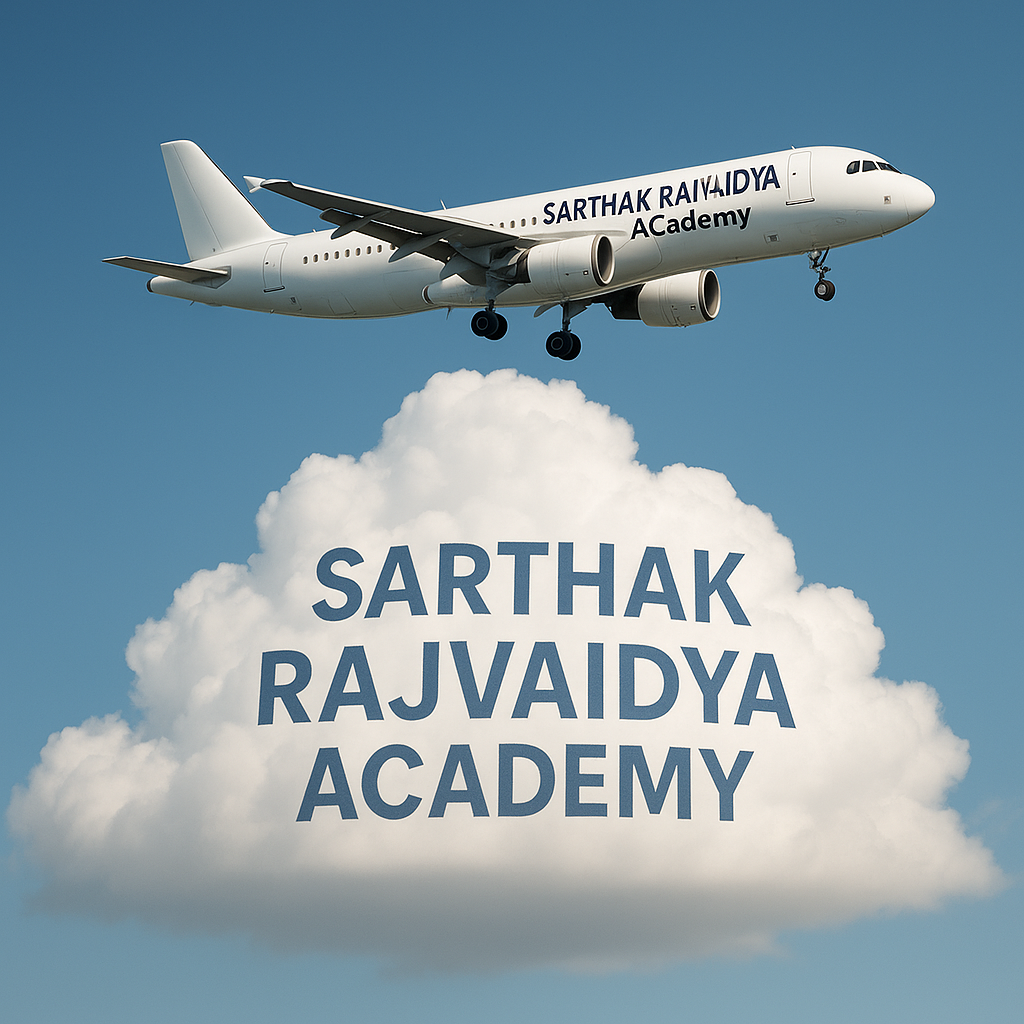

In [19]:
import base64

from IPython.display import Image as ShowImage, display

from meshapi import ImageGenerationParams

IMAGE_MODEL = "openai/gpt-image-1"

img = client.images.generate(
    ImageGenerationParams(prompt="an airplane above a cloud , and its writting Sarthak Rajvaidya academy on cloud", model=IMAGE_MODEL, n=1, size="1024x1024", response_format="b64_json")
)

img_bytes = base64.b64decode(img.data[0].b64_json)
with open("generated_airplane.png", "wb") as f:
    f.write(img_bytes)
print(f"Saved generated_airplane.png ({len(img_bytes)} bytes)")
display(ShowImage(img_bytes, width=256))


3.2 Image editing
Inpaint, outpaint, remove background, upscale, mix images, and more -- here we remove the background from the image we just generated.

Saved generated_robot_nobg.png (1513371 bytes)


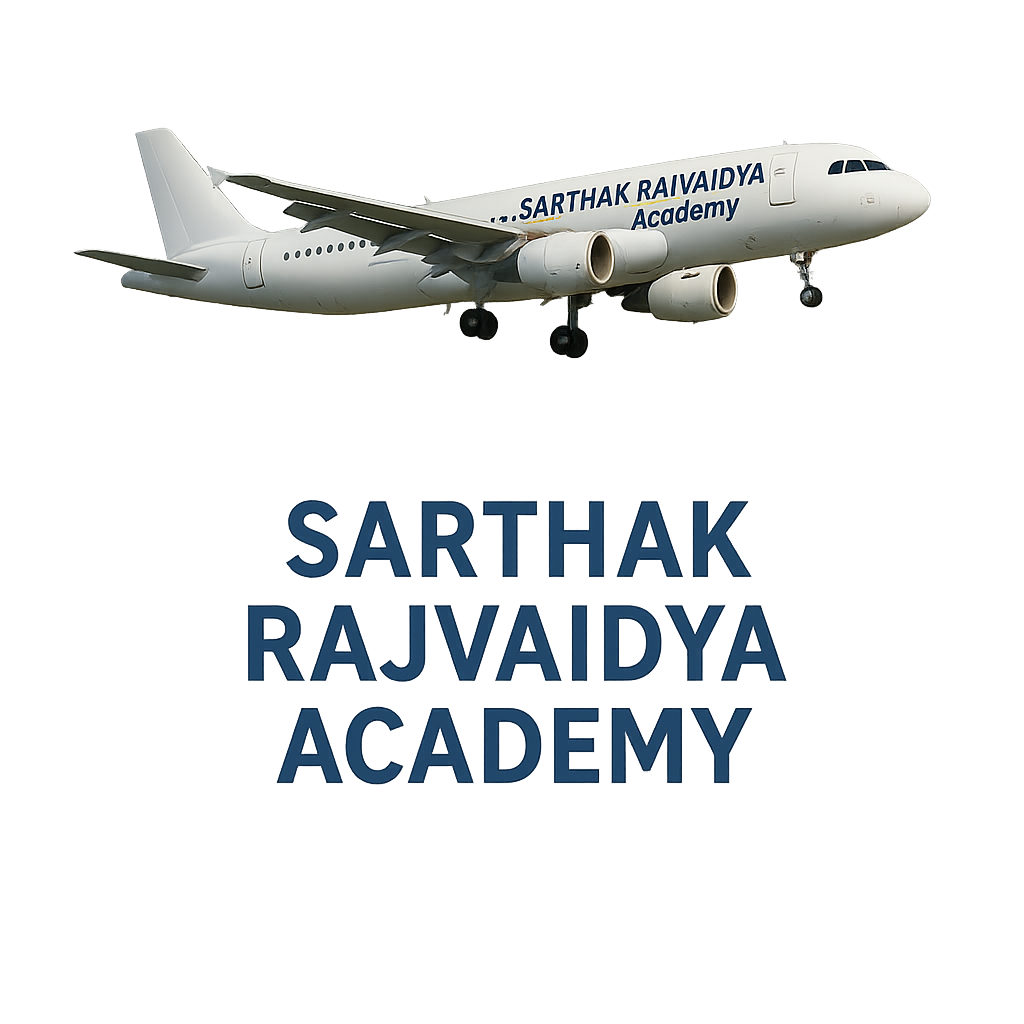

In [20]:
from meshapi import ImageEditParams

data_url = f"data:image/png;base64,{base64.b64encode(img_bytes).decode()}"

edited = client.images.edit(
    ImageEditParams(model=IMAGE_MODEL, image=data_url, operation="remove_background", response_format="b64_json")
)

edited_bytes = base64.b64decode(edited.data[0].b64_json)
with open("generated_robot_nobg.png", "wb") as f:
    f.write(edited_bytes)
print(f"Saved generated_robot_nobg.png ({len(edited_bytes)} bytes)")
display(ShowImage(edited_bytes, width=256))


3.3 Video generation:- Text/image prompt -> a short generated video clip. This is async: you create a task, then poll it. Kept to ~3 seconds of video to stay cheap and fast (this one took about 30 seconds to finish).

In [21]:
from meshapi import VideoGenerationParams, VideoContentItem

VIDEO_MODEL = "byteplus/seedance-1-0-pro-fast"

task = client.videos.generate(
    VideoGenerationParams(
        model=VIDEO_MODEL,
        content=[VideoContentItem(type="text", text="a small girl in a red skirt waving hello Sarthak Rajvaidya, simple animation")],
    )
)
print("task created:", task.id)

video_url = None
for i in range(12):
    t = client.videos.retrieve(task.id)
    print(f"poll {i}: status={t.status}")
    if t.status == "succeeded":
        video_url = t.content.video_url
        break
    if t.status in ("failed", "expired", "cancelled"):
        print("did not succeed:", t.error)
        break
    time.sleep(5)

if video_url:
    print("video url (signed, expires soon):", video_url[:80], "...")

MeshAPIError: Insufficient balance to start a video generation task. Top up your account to continue.

### Result

The Video Generation API was successfully reached, but MeshAPI
rejected the request because the account did not have sufficient
balance to start a video generation task.

This demonstrates that video generation is a paid feature and
requires sufficient account balance before a generation task can
be created.

3.4 Text-to-speech (TTS) :- ext -> spoken audio. Two things worth knowing from testing this live: the model needs its full provider/model id (not the bare model name), and ElevenLabs models require an explicit voice

In [22]:
from IPython.display import Audio as ShowAudio

from meshapi import SpeechParams

TTS_MODEL = "hexgrad/kokoro-82m"

speech_bytes = client.audio.synthesize(
    SpeechParams(input="MeshAPI is a gateway for many AI models.", model=TTS_MODEL, voice="af_heart", stream=False)
)

with open("speech.mp3", "wb") as f:
    f.write(speech_bytes)
print(f"Saved speech.mp3 ({len(speech_bytes)} bytes)")
display(ShowAudio("speech.mp3"))


Saved speech.mp3 (22368 bytes)


3.5 Speech-to-text (STT)

In [23]:
from meshapi import TranscriptionParams

STT_MODEL = "elevenlabs/scribe_v1"

with open("speech.mp3", "rb") as f:
    audio_data = f.read()

transcript = client.audio.transcribe(audio_data, TranscriptionParams(model=STT_MODEL), filename="speech.mp3")
print("original text: MeshAPI is a gateway for many AI models.")
print("transcribed:  ", transcript.text)


original text: MeshAPI is a gateway for many AI models.
transcribed:   Mesh API is a gateway for many AI models


3.6 Audio translation :- Audio in one language -> transcript/translation in another (here, same-language, just to prove the endpoint works -- try it with non-English audio for the real use case).

In [24]:
from meshapi import AudioTranslationsParams

AUDIO_TRANSLATE_MODEL = "openai/whisper-large-v3"

with open("speech.mp3", "rb") as f:
    audio_data = f.read()

translated = client.audio.audio_translate(audio_data, AudioTranslationsParams(model=AUDIO_TRANSLATE_MODEL), filename="speech.mp3")
print(translated.text)


Mesh API is a gateway for many AI models.


3.7 Realtime speech-to-speech
A live, two-way voice conversation over a WebSocket. A full audio-streaming demo needs a microphone/speaker pipeline that doesn't fit cleanly in a notebook -- so this is a connection-only test: open the session, confirm the handshake works, close it. That's enough to prove the feature is reachable; wiring up real audio I/O is an app-level task, not a notebook cell.

In [25]:
with client.realtime.connect(model="openai/gpt-realtime-mini") as session:

    print("Realtime session opened successfully:", type(session).__name__)

print("Session closed cleanly.")


Realtime session opened successfully: RealtimeSession
Session closed cleanly.


4. Safety & moderation
4.1 Moderations
Checks text (or images) for 13 categories of unsafe content, each with a flag and a confidence score.

In [26]:
from meshapi import ModerationParams

result = client.moderations.create(ModerationParams(input="I want to kill someone"))

r = result.results[0]

print("flagged:", r.flagged)

flagged_categories = {k: v for k, v in r.category_scores.items() if v > 0.1}

print("categories with notable scores:", flagged_categories)


flagged: True
categories with notable scores: {'harassment': 0.3416197214080141, 'harassment/threatening': 0.28511518156125304, 'illicit': 0.16753711744558777, 'violence': 0.9528311271625413}


5. Reliability & cost

5.1 Automatic retry & fallback
If a provider is slow or down, MeshAPI retries, then tries a different provider, then a similar model -- automatically, with zero code changes on our end. We can't force a real provider outage on demand, but every response carries headers showing what happened, even when nothing went wrong:

In [27]:
resp = requests.post(f"{MESHAPI_BASE_URL}/v1/chat/completions", headers=RAW_HEADERS,

                     json={"model": FAST_MODEL, "messages": [{"role": "user", "content": "hi"}], "max_tokens": 5})

attempts = resp.headers.get("x-mesh-routing-attempts")

fallback = resp.headers.get("x-mesh-routing-fallback")

print("X-Mesh-Routing-Attempts:", attempts if attempts is not None else "(not sent on this response)")

print("X-Mesh-Routing-Fallback:", fallback if fallback is not None else "(not sent on this response)")

print("These headers show up when MeshAPI's routing logic is exercised -- absent/1-attempt means it just worked.")


X-Mesh-Routing-Attempts: 1
X-Mesh-Routing-Fallback: false
These headers show up when MeshAPI's routing logic is exercised -- absent/1-attempt means it just worked.


5.2 Response caching
Identical requests (temperature 0, no tools) are cached free for 24 hours. Send the exact same request twice and watch the X-Cache header change from a miss to a hit:

In [28]:
body = {"model": FAST_MODEL, "messages": [{"role": "user", "content": "What is the capital of inida? One word."}], "temperature": 0, "max_tokens": 10}



r1 = requests.post(f"{MESHAPI_BASE_URL}/v1/chat/completions", headers=RAW_HEADERS, json=body)

print("call 1 -> X-Cache:", r1.headers.get("X-Cache", "(miss, no header)"))



r2 = requests.post(f"{MESHAPI_BASE_URL}/v1/chat/completions", headers=RAW_HEADERS, json=body)

print("call 2 -> X-Cache:", r2.headers.get("X-Cache", "(miss, no header)"), "  <- free, cached, instant")


call 1 -> X-Cache: (miss, no header)
call 2 -> X-Cache: (miss, no header)   <- free, cached, instant


5.3 Batch API
Submit many requests as one job, cheaper than real-time, processed within a time window (e.g. 24h). Not every model supports batching -- check supports_batching on the model catalog first. We submit a tiny 2-request batch and show the status lifecycle; it likely won't fully complete during this notebook run (that's expected -- production batches are meant to run in the background for hours).

In [29]:
from meshapi import CreateBatchParams, BatchRequestItem

# Not every model supports batching -- openai/gpt-4.1 does (confirmed live).
batch_model = "openai/gpt-4.1"
print("using batch-capable model:", batch_model)

batch = client.batches.create(CreateBatchParams(
    requests=[
        BatchRequestItem(custom_id="req-1", body={"model": batch_model, "messages": [{"role": "user", "content": "Say A"}], "max_tokens": 5}),
        BatchRequestItem(custom_id="req-2", body={"model": batch_model, "messages": [{"role": "user", "content": "Say B"}], "max_tokens": 5}),
    ],
    completion_window="24h",
))
print("batch id:", batch.id, "| status:", batch.status)

b = client.batches.get(batch.id)
print("status a few seconds later:", b.status, "(normal for it to still be 'validating' / 'in_progress' here)")


using batch-capable model: openai/gpt-4.1
batch id: batch_6a9e9635f34081908e276d45c8235bd8 | status: validating
status a few seconds later: validating (normal for it to still be 'validating' / 'in_progress' here)
